ERROR:2025-08-31 22:04:46,720:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/gfertt/.local/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/gfertt/.local/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/gfertt/.local/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 100; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


Within-model accept rate: 0.891316685584563
Posterior mean of k: 1.03025


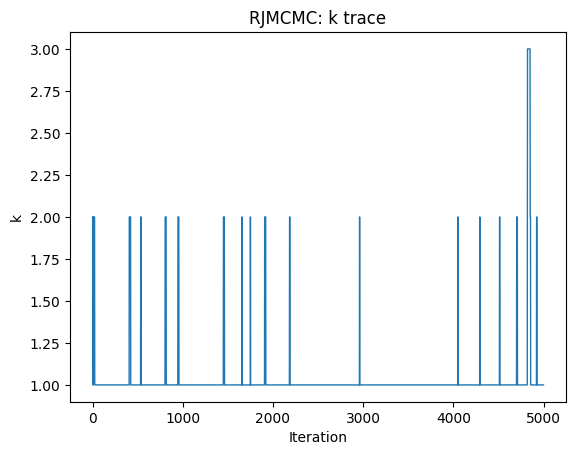

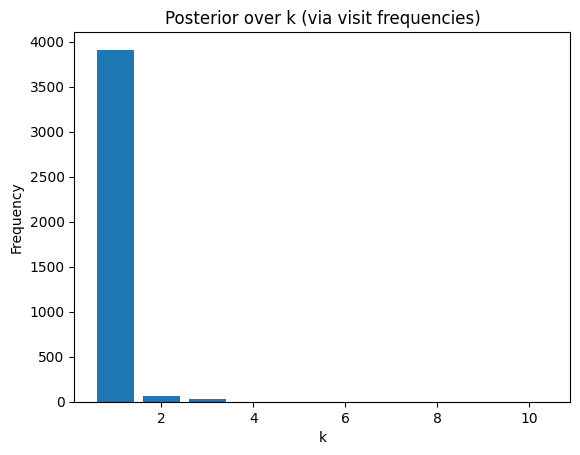

Number of stored parameter draws: 200
Example draw keys: ['alpha', 'beta']
alpha shape: (1,)
beta shape: (1,)


In [1]:
"""
RJMCMC TEMPLATE (NumPyro + JAX): birth/death + within-model MH
----------------------------------------------------------------
This is a practical template for reversible-jump MCMC when your model uses
parameter *vectors* whose length is k (the model index). It mixes:
  • within-model Metropolis steps on continuous parameters, and
  • trans-dimensional birth/death moves (k ↔ k±1) with correct RJ ratios.

You provide:
  1) loglik_fn(data, params) -> scalar log-likelihood.
     - `params` is a dict of 1D arrays (each of length k), one per parameter vector.
  2) priors per-parameter-vector (NumPyro distributions) — assumed i.i.d. over the k entries.
  3) an optional birth proposal (defaults to using the prior as proposal).

Notes
-----
• PRNG keys: typed as jax.Array for wide compatibility (use Any or jnp.ndarray if your JAX version lacks jax.Array).
• This template keeps things simple and Pythonic (not fully JITed). Start here,
  then optimize/port pieces to JAX transforms if needed.
• Jacobian terms are 0 (|J|=1) for basic birth/death of i.i.d. component entries.
  For split/merge or constrained transforms, add the Jacobian in the acceptance ratio.
• If some parameter vectors have constraints (e.g., positive, simplex), either
  (a) use appropriate priors (LogNormal, Dirichlet, etc.) and proposals that
      respect the support, or
  (b) reparameterize (unconstrain) and adjust with a Jacobian.
• If you want to combine with NUTS/HMC for within-model updates, you can replace
  `gaussian_rw_within_model` with a short conditional HMC step on the current
  dimension; doing that cleanly usually means writing a custom kernel or using a
  product-space trick. This template stays in MH-land for clarity.

Minimal usage (sketch)
----------------------
1) Fill in `loglik_fn` for your model.
2) Define priors for each parameter vector field, e.g.:
      priors = {
          'alpha': dist.Normal(0., 1.),   # alpha has shape (k,)
          'beta':  dist.LogNormal(0., 0.5)
      }
3) Run:
      key = random.PRNGKey(0)
      chain = run_rjmcmc(key, data, loglik_fn, priors,
                         cfg=RJMCMCConfig(k_init=2, k_min=0, k_max=20, num_iters=20_000))
4) Inspect:
      k_trace = np.array(chain['k'])
      params_samples = chain['params']  # list of dicts every `thin` steps

"""
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple, Any

import jax
import jax.numpy as jnp
import numpy as np
from numpyro import distributions as dist
from jax import random

# -----------------------------
# Config & helpers
# -----------------------------

@dataclass
class RJMCMCConfig:
    k_init: int
    k_min: int = 0
    k_max: int = 50
    num_iters: int = 10_000
    burn_in: int = 1_000
    thin: int = 10
    p_within: float = 0.7      # probability of a within-model parameter update
    p_birth: float = 0.5       # if doing a trans-dim move, prob of birth vs. death
    rw_scale: float = 0.1      # random-walk std for within-model MH
    record_params: bool = True # store parameter snapshots (every `thin`)

# Prior over k (model size). Default: truncated geometric with parameter p.
# Feel free to replace with Poisson or your own function.
@dataclass
class KPrior:
    p: float = 0.3  # P(K=k) ∝ (1-p)^k p  (truncated to [k_min, k_max])

    def log_prob(self, k: int, k_min: int, k_max: int) -> float:
        if (k < k_min) or (k > k_max):
            return -jnp.inf
        # Unnormalized log-prob (normalizing constant cancels in RJ ratios if support stays same)
        return jnp.log(self.p) + k * jnp.log(1.0 - self.p)

# Convenience: log prior for params = sum over fields and over entries (i.i.d. assumption)
def log_prior_params(params: Dict[str, jnp.ndarray], priors: Dict[str, dist.Distribution]) -> jnp.ndarray:
    logp = 0.0
    for name, values in params.items():
        d = priors[name]
        # d.log_prob(values) returns shape (k,), sum over entries
        logp = logp + jnp.sum(d.log_prob(values))
    return logp

# Convenience: sample an initial params dict of length k from priors
def sample_params_from_priors(key: jax.Array, k: int, priors: Dict[str, dist.Distribution]) -> Dict[str, jnp.ndarray]:
    out = {}
    for i, (name, d) in enumerate(priors.items()):
        key, sub = random.split(key)
        # Broadcast sample to shape (k,)
        out[name] = d.sample(sub, sample_shape=(k,))
    return out

# Birth proposal: by default, sample a new component from priors (proposal == prior)
# Returns (new_component_dict, log_q_forward)
# For more tailored proposals, modify this.
def propose_birth_component(key: jax.Array,
                           priors: Dict[str, dist.Distribution]) -> Tuple[Dict[str, jnp.ndarray], jnp.ndarray]:
    new_comp = {}
    log_q = 0.0
    for name, d in priors.items():
        key, sub = random.split(key)
        x = d.sample(sub)        # scalar sample for one new entry
        new_comp[name] = jnp.atleast_1d(x)[0]
        log_q = log_q + d.log_prob(new_comp[name])
    return new_comp, log_q

# Reverse density for death move uses the same birth proposal (if symmetric design)
def log_q_birth(new_comp: Dict[str, jnp.ndarray], priors: Dict[str, dist.Distribution]) -> jnp.ndarray:
    log_q = 0.0
    for name, d in priors.items():
        log_q = log_q + d.log_prob(new_comp[name])
    return log_q

# Insert / delete a component across all parameter vectors

def append_component(params: Dict[str, jnp.ndarray], comp: Dict[str, jnp.ndarray]) -> Dict[str, jnp.ndarray]:
    new_params = {}
    for name, arr in params.items():
        new_params[name] = jnp.concatenate([arr, jnp.array([comp[name]])], axis=0)
    return new_params


def remove_component(params: Dict[str, jnp.ndarray], idx: int) -> Dict[str, jnp.ndarray]:
    new_params = {}
    for name, arr in params.items():
        new_params[name] = jnp.concatenate([arr[:idx], arr[idx+1:]], axis=0)
    return new_params

# -----------------------------
# Within-model random-walk MH
# -----------------------------

def gaussian_rw_within_model(key: jax.Array,
                             params: Dict[str, jnp.ndarray],
                             loglik_fn: Callable[[Any, Dict[str, jnp.ndarray]], jnp.ndarray],
                             data: Any,
                             priors: Dict[str, dist.Distribution],
                             rw_scale: float) -> Tuple[jax.Array, Dict[str, jnp.ndarray]]:
    """One symmetric Gaussian random-walk proposal across all entries, all fields."""
    key, sub = random.split(key)
    proposal = {}
    for name, arr in params.items():
        noise = random.normal(sub, shape=arr.shape) * rw_scale
        # split again for next field
        key, sub = random.split(key)
        proposal[name] = arr + noise

    # MH acceptance
    curr_lp = loglik_fn(data, params) + log_prior_params(params, priors)
    prop_lp = loglik_fn(data, proposal) + log_prior_params(proposal, priors)
    accept = jnp.log(random.uniform(key)) < (prop_lp - curr_lp)
    new_params = jax.tree_util.tree_map(lambda a, b: jnp.where(accept, a, b), proposal, params)
    return key, new_params

# -----------------------------
# RJ birth/death move
# -----------------------------

def rj_birth_move(key: jax.Array,
                  k: int,
                  params: Dict[str, jnp.ndarray],
                  loglik_fn: Callable[[Any, Dict[str, jnp.ndarray]], jnp.ndarray],
                  data: Any,
                  priors: Dict[str, dist.Distribution],
                  k_prior: KPrior,
                  k_min: int,
                  k_max: int) -> Tuple[jax.Array, int, Dict[str, jnp.ndarray]]:
    if k >= k_max:
        return key, k, params  # invalid; skip

    key, sub = random.split(key)
    new_comp, log_q_fwd = propose_birth_component(sub, priors)
    new_params = append_component(params, new_comp)

    # Log probabilities
    curr_lp = loglik_fn(data, params) + log_prior_params(params, priors) + k_prior.log_prob(k, k_min, k_max)
    prop_lp = loglik_fn(data, new_params) + log_prior_params(new_params, priors) + k_prior.log_prob(k+1, k_min, k_max)

    # Reverse move: death would choose one of (k+1) components uniformly to delete
    log_q_rev = -jnp.log(k + 1.0) + log_q_birth(new_comp, priors)
    # Forward: birth chooses to add exactly this component (we *sampled* it)
    # and we also choose an insertion position uniformly at end; treat as 1 choice
    log_q_fwd_total = log_q_fwd  # (no Jacobian for simple insert)

    log_alpha = (prop_lp - curr_lp) + (log_q_rev - log_q_fwd_total)

    key, akey = random.split(key)
    accept = jnp.log(random.uniform(akey)) < log_alpha
    if bool(accept):
        return key, k + 1, new_params
    else:
        return key, k, params


def rj_death_move(key: jax.Array,
                  k: int,
                  params: Dict[str, jnp.ndarray],
                  loglik_fn: Callable[[Any, Dict[str, jnp.ndarray]], jnp.ndarray],
                  data: Any,
                  priors: Dict[str, dist.Distribution],
                  k_prior: KPrior,
                  k_min: int,
                  k_max: int) -> Tuple[jax.Array, int, Dict[str, jnp.ndarray]]:
    if k <= k_min:
        return key, k, params  # invalid; skip

    # Choose a component uniformly to delete
    key, sub = random.split(key)
    idx = random.randint(sub, (), 0, k)

    # Component values being removed
    removed_comp = {name: arr[idx] for name, arr in params.items()}

    new_params = remove_component(params, int(idx))

    curr_lp = loglik_fn(data, params) + log_prior_params(params, priors) + k_prior.log_prob(k, k_min, k_max)
    prop_lp = loglik_fn(data, new_params) + log_prior_params(new_params, priors) + k_prior.log_prob(k-1, k_min, k_max)

    # Reverse: birth would sample a component from q_birth and *also* choose a position (k choices after death)
    log_q_rev = log_q_birth(removed_comp, priors)
    # Forward: we chose which index to delete uniformly among k
    log_q_fwd_total = -jnp.log(float(k))

    log_alpha = (prop_lp - curr_lp) + (log_q_rev - log_q_fwd_total)

    key, akey = random.split(key)
    accept = jnp.log(random.uniform(akey)) < log_alpha
    if bool(accept):
        return key, k - 1, new_params
    else:
        return key, k, params

# -----------------------------
# Main RJMCMC driver
# -----------------------------

def run_rjmcmc(key: jax.Array,
               data: Any,
               loglik_fn: Callable[[Any, Dict[str, jnp.ndarray]], jnp.ndarray],
               priors: Dict[str, dist.Distribution],
               cfg: RJMCMCConfig = RJMCMCConfig(k_init=1),
               k_prior: KPrior = KPrior()) -> Dict[str, Any]:
    """Run mixed within-model MH + RJ birth/death.

    Returns dict with traces: 'k' (list[int]), 'accept_rate_within', 'params' (snapshots).
    """
    key_init = key
    # init
    key, sub = random.split(key)
    k = int(cfg.k_init)
    params = sample_params_from_priors(sub, k, priors)

    # traces
    k_trace: List[int] = []
    params_trace: List[Dict[str, np.ndarray]] = []
    n_accept_within = 0
    n_within = 0

    for t in range(cfg.num_iters):
        key, sub = random.split(key)
        u = random.uniform(sub)

        if u < cfg.p_within:
            # within-model MH
            n_within += 1
            key, new_params = gaussian_rw_within_model(key, params, loglik_fn, data, priors, cfg.rw_scale)
            # Determine acceptance by identity comparison (arrays equal iff reject path kept old params)
            # We compute acceptance by recomputing logs (cheap) for clarity.
            curr_lp = loglik_fn(data, params) + log_prior_params(params, priors)
            prop_lp = loglik_fn(data, new_params) + log_prior_params(new_params, priors)
            accepted = bool(prop_lp > curr_lp) or (float(np.log(np.random.rand())) < float(prop_lp - curr_lp))
            if accepted:
                params = new_params
                n_accept_within += 1
        else:
            # trans-dimensional move
            key, sub = random.split(key)
            do_birth = (k < cfg.k_max) and ((k == cfg.k_min) or (random.uniform(sub) < cfg.p_birth))
            if do_birth:
                key, k, params = rj_birth_move(key, k, params, loglik_fn, data, priors, k_prior, cfg.k_min, cfg.k_max)
            else:
                key, k, params = rj_death_move(key, k, params, loglik_fn, data, priors, k_prior, cfg.k_min, cfg.k_max)

        # record
        k_trace.append(int(k))
        if cfg.record_params and ((t >= cfg.burn_in) and (t % cfg.thin == 0)):
            # store as numpy arrays to keep them outside JAX device memory
            params_trace.append({name: np.array(arr) for name, arr in params.items()})

    accept_rate_within = (n_accept_within / max(n_within, 1))

    return {
        'k': k_trace,
        'params': params_trace,
        'accept_rate_within': accept_rate_within,
        'config': cfg,
        'key_init': key_init,
    }

# -----------------------------
# Example log-likelihood placeholder (replace with your model)
# -----------------------------

def example_loglik_fn(data: Dict[str, jnp.ndarray], params: Dict[str, jnp.ndarray]) -> jnp.ndarray:
    """Toy example: y ~ Normal(f(params), sigma) with fixed sigma.
    Safe for k=0 (empty parameter vectors): we treat the mean of an empty vector as 0.
    """
    y = data['y']           # shape (N,)
    sigma = data.get('sigma', 1.0)

    def safe_mean(x: jnp.ndarray) -> jnp.ndarray:
        return jnp.where(x.size > 0, jnp.mean(x), 0.0)

    pred_mean = 0.0
    for name, arr in params.items():
        pred_mean = pred_mean + safe_mean(arr)

    ll = jnp.sum(dist.Normal(pred_mean, sigma).log_prob(y))
    return ll

# -----------------------------
# Tips for adaptation
# -----------------------------
# • If each component represents a *cluster* (e.g., in a mixture), then each parameter
#   vector is per-component (e.g., means, variances). Your loglik_fn should compute
#   the data likelihood under those components — typically a sum over data points and
#   a log-sum-exp over components.
# • For label symmetry, consider ordering or a post-hoc relabeling step when analyzing
#   the samples.
# • To upgrade within-model mixing, target only a random subset of entries per step, or
#   parameter-wise scales. For HMC/NUTS within k, consider running a short conditional
#   MCMC inside the main loop.
# • For split/merge moves, define a bijection g with non-trivial Jacobian and add its
#   log|J| to the acceptance ratio in rj_birth_move / rj_death_move variants.
# • To encode constraints like sum-to-one weights, reparameterize via unconstrained
#   variables and a softmax map; include the transform’s Jacobian in priors/proposals.

# =============================
# Example usage (copy/paste runnable)
# =============================
if __name__ == "__main__":
    # --- 1) Create synthetic data for the toy example_loglik_fn ---
    key = random.PRNGKey(42)
    N = 200
    sigma = 1.0

    # True (unknown) number of components
    k_true = 3

    # Two parameter vectors, each length k (to match the priors below)
    key, k1, k2 = random.split(key, 3)
    alpha_true = dist.Normal(0., 1.).sample(k1, sample_shape=(k_true,))
    beta_true  = dist.LogNormal(0., 0.5).sample(k2, sample_shape=(k_true,))

    # The toy forward model in example_loglik_fn uses: mean(y) = mean(alpha)+mean(beta)
    pred_mean_true = jnp.mean(alpha_true) + jnp.mean(beta_true)
    key, sub = random.split(key)
    y = dist.Normal(pred_mean_true, sigma).sample(sub, sample_shape=(N,))

    data = {"y": y, "sigma": sigma}

    # --- 2) Define priors for each parameter vector field ---
    priors = {
        "alpha": dist.Normal(0., 1.),
        "beta":  dist.LogNormal(0., 0.5),
    }

    # --- 3) Configure and run RJMCMC ---
    cfg = RJMCMCConfig(
        k_init=2,
        k_min=1,          # avoid k=0 unless your model defines a proper null likelihood
        k_max=10,
        num_iters=5000,   # increase for real runs
        burn_in=1000,
        thin=20,
        p_within=0.7,
        p_birth=0.5,
        rw_scale=0.05,
        record_params=True,
    )

    out = run_rjmcmc(key, data, example_loglik_fn, priors, cfg)

    # --- 4) Inspect results ---
    k_trace = np.array(out["k"])                 # model index over time
    print("Within-model accept rate:", out["accept_rate_within"])  # rough diagnostic
    print("Posterior mean of k:", k_trace[cfg.burn_in:].mean())

    # Optional quicklook plots (requires matplotlib)
    try:
        import matplotlib.pyplot as plt
        plt.figure()
        plt.plot(k_trace, lw=1)
        plt.xlabel("Iteration")
        plt.ylabel("k")
        plt.title("RJMCMC: k trace")
        plt.show()

        plt.figure()
        plt.hist(k_trace[cfg.burn_in:], bins=range(cfg.k_min, cfg.k_max+2), align='left', rwidth=0.8)
        plt.xlabel("k")
        plt.ylabel("Frequency")
        plt.title("Posterior over k (via visit frequencies)")
        plt.show()
    except Exception as e:
        print("(Plotting skipped)", e)

    # Access parameter snapshots after burn-in/thinning
    print("Number of stored parameter draws:", len(out["params"]))
    if len(out["params"]) > 0:
        example_draw = out["params"][0]
        print("Example draw keys:", list(example_draw.keys()))
        for name, arr in example_draw.items():
            print(f"{name} shape:", arr.shape)  # each is (k_current,)

    # Tip: for more realistic models, replace example_loglik_fn with your own,
    # keeping the {name: vector_of_len_k} parameter structure.

# ===============
# Advanced sketch: swapping in your own loglik
# ===============
# def my_loglik_fn(data, params):
#     """Example structure if your forward model maps k-length vectors -> predictions.
#     Suppose your model prediction is f(params; k) producing y_hat of shape (N,).
#     Then set: y ~ Normal(y_hat, sigma).
#     """
#     y = data['y']
#     sigma = data.get('sigma', 1.0)
#     # y_hat = forward_model(params)  # <-- your deterministic mapping using all parameter vectors
#     # return jnp.sum(dist.Normal(y_hat, sigma).log_prob(y))
#     raise NotImplementedError



Within-model accept rate: 0.8921679909194098
Posterior mean of k: 1.04825


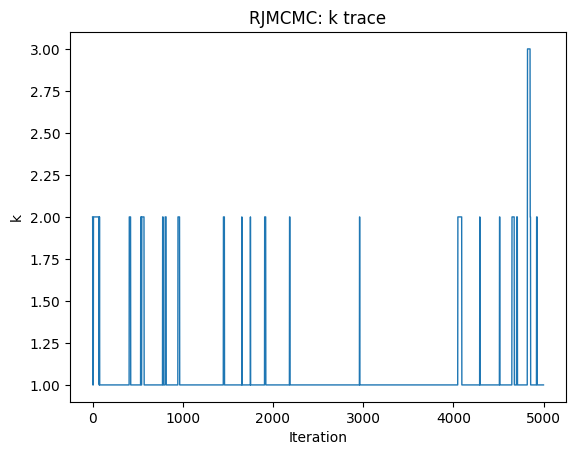

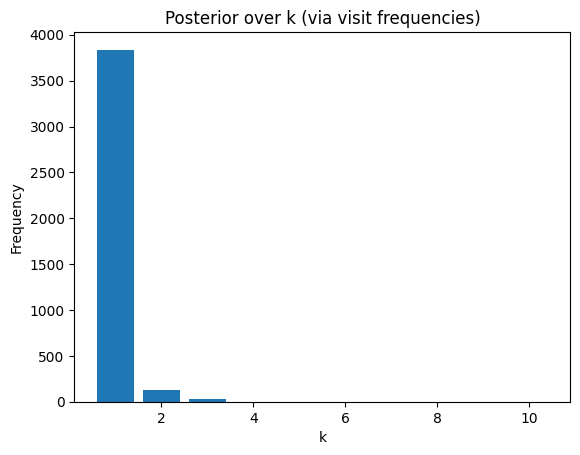

Number of stored parameter draws: 200
Example draw keys: ['alpha', 'beta']
alpha shape: (1,)
beta shape: (1,)


In [3]:
"""
RJMCMC TEMPLATE (NumPyro + JAX): birth/death + within-model MH
----------------------------------------------------------------
This is a practical template for reversible-jump MCMC when your model uses
parameter *vectors* whose length is k (the model index). It mixes:
  • within-model Metropolis steps on continuous parameters, and
  • trans-dimensional birth/death moves (k ↔ k±1) with correct RJ ratios.

You provide:
  1) loglik_fn(data, params) -> scalar log-likelihood.
     - `params` is a dict of 1D arrays (each of length k), one per parameter vector.
  2) priors per-parameter-vector (NumPyro distributions) — assumed i.i.d. over the k entries.
  3) an optional birth proposal (defaults to using the prior as proposal).

Notes
-----
• PRNG keys: typed as Any for wide compatibility (use Any or jnp.ndarray if your JAX version lacks Any).
• This template keeps things simple and Pythonic (not fully JITed). Start here,
  then optimize/port pieces to JAX transforms if needed.
• Jacobian terms are 0 (|J|=1) for basic birth/death of i.i.d. component entries.
  For split/merge or constrained transforms, add the Jacobian in the acceptance ratio.
• If some parameter vectors have constraints (e.g., positive, simplex), either
  (a) use appropriate priors (LogNormal, Dirichlet, etc.) and proposals that
      respect the support, or
  (b) reparameterize (unconstrain) and adjust with a Jacobian.
• If you want to combine with NUTS/HMC for within-model updates, you can replace
  `gaussian_rw_within_model` with a short conditional HMC step on the current
  dimension; doing that cleanly usually means writing a custom kernel or using a
  product-space trick. This template stays in MH-land for clarity.

Minimal usage (sketch)
----------------------
1) Fill in `loglik_fn` for your model.
2) Define priors for each parameter vector field, e.g.:
      priors = {
          'alpha': dist.Normal(0., 1.),   # alpha has shape (k,)
          'beta':  dist.LogNormal(0., 0.5)
      }
3) Run:
      key = random.PRNGKey(0)
      chain = run_rjmcmc(key, data, loglik_fn, priors,
                         cfg=RJMCMCConfig(k_init=2, k_min=0, k_max=20, num_iters=20_000))
4) Inspect:
      k_trace = np.array(chain['k'])
      params_samples = chain['params']  # list of dicts every `thin` steps

"""
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple, Any

import jax
import jax.numpy as jnp
import numpy as np
from numpyro import distributions as dist
from jax import random

# -----------------------------
# Config & helpers
# -----------------------------

@dataclass
class RJMCMCConfig:
    k_init: int
    k_min: int = 0
    k_max: int = 50
    num_iters: int = 10_000
    burn_in: int = 1_000
    thin: int = 10
    p_within: float = 0.7      # probability of a within-model parameter update
    p_birth: float = 0.5       # if doing a trans-dim move, prob of birth vs. death
    rw_scale: float = 0.1      # random-walk std for within-model MH
    record_params: bool = True # store parameter snapshots (every `thin`)

# Prior over k (model size). Default: truncated geometric with parameter p.
# Feel free to replace with Poisson or your own function.
@dataclass
class KPrior:
    p: float = 0.3  # P(K=k) ∝ (1-p)^k p  (truncated to [k_min, k_max])

    def log_prob(self, k: int, k_min: int, k_max: int) -> float:
        if (k < k_min) or (k > k_max):
            return -jnp.inf
        # Unnormalized log-prob (normalizing constant cancels in RJ ratios if support stays same)
        return jnp.log(self.p) + k * jnp.log(1.0 - self.p)

# Convenience: log prior for params = sum over fields and over entries (i.i.d. assumption)
def log_prior_params(params: Dict[str, jnp.ndarray], priors: Dict[str, dist.Distribution]) -> jnp.ndarray:
    logp = 0.0
    for name, values in params.items():
        d = priors[name]
        # d.log_prob(values) returns shape (k,), sum over entries
        logp = logp + jnp.sum(d.log_prob(values))
    return logp

# Convenience: sample an initial params dict of length k from priors
def sample_params_from_priors(key: Any, k: int, priors: Dict[str, dist.Distribution]) -> Dict[str, jnp.ndarray]:
    out = {}
    for i, (name, d) in enumerate(priors.items()):
        key, sub = random.split(key)
        # Broadcast sample to shape (k,)
        out[name] = d.sample(sub, sample_shape=(k,))
    return out

# Birth proposal: by default, sample a new component from priors (proposal == prior)
# Returns (new_component_dict, log_q_forward)
# For more tailored proposals, modify this.
def propose_birth_component(key: Any,
                           priors: Dict[str, dist.Distribution]) -> Tuple[Dict[str, jnp.ndarray], jnp.ndarray]:
    new_comp = {}
    log_q = 0.0
    for name, d in priors.items():
        key, sub = random.split(key)
        x = d.sample(sub)        # scalar sample for one new entry
        new_comp[name] = jnp.atleast_1d(x)[0]
        log_q = log_q + d.log_prob(new_comp[name])
    return new_comp, log_q

# Reverse density for death move uses the same birth proposal (if symmetric design)
def log_q_birth(new_comp: Dict[str, jnp.ndarray], priors: Dict[str, dist.Distribution]) -> jnp.ndarray:
    log_q = 0.0
    for name, d in priors.items():
        log_q = log_q + d.log_prob(new_comp[name])
    return log_q

# Insert / delete a component across all parameter vectors

def append_component(params: Dict[str, jnp.ndarray], comp: Dict[str, jnp.ndarray]) -> Dict[str, jnp.ndarray]:
    new_params = {}
    for name, arr in params.items():
        new_params[name] = jnp.concatenate([arr, jnp.array([comp[name]])], axis=0)
    return new_params


def remove_component(params: Dict[str, jnp.ndarray], idx: int) -> Dict[str, jnp.ndarray]:
    new_params = {}
    for name, arr in params.items():
        new_params[name] = jnp.concatenate([arr[:idx], arr[idx+1:]], axis=0)
    return new_params

# -----------------------------
# Within-model random-walk MH
# -----------------------------

def gaussian_rw_within_model(key: Any,
                             params: Dict[str, jnp.ndarray],
                             loglik_fn: Callable[[Any, Dict[str, jnp.ndarray]], jnp.ndarray],
                             data: Any,
                             priors: Dict[str, dist.Distribution],
                             rw_scale: float) -> Tuple[Any, Dict[str, jnp.ndarray]]:
    """One symmetric Gaussian random-walk proposal across all entries, all fields."""
    key, sub = random.split(key)
    proposal = {}
    for name, arr in params.items():
        noise = random.normal(sub, shape=arr.shape) * rw_scale
        # split again for next field
        key, sub = random.split(key)
        proposal[name] = arr + noise

    # MH acceptance
    curr_lp = loglik_fn(data, params) + log_prior_params(params, priors)
    prop_lp = loglik_fn(data, proposal) + log_prior_params(proposal, priors)
    accept = jnp.log(random.uniform(key)) < (prop_lp - curr_lp)
    new_params = jax.tree_util.tree_map(lambda a, b: jnp.where(accept, a, b), proposal, params)
    return key, new_params

# -----------------------------
# RJ birth/death move
# -----------------------------

def rj_birth_move(key: Any,
                  k: int,
                  params: Dict[str, jnp.ndarray],
                  loglik_fn: Callable[[Any, Dict[str, jnp.ndarray]], jnp.ndarray],
                  data: Any,
                  priors: Dict[str, dist.Distribution],
                  k_prior: KPrior,
                  k_min: int,
                  k_max: int) -> Tuple[Any, int, Dict[str, jnp.ndarray]]:
    if k >= k_max:
        return key, k, params  # invalid; skip

    key, sub = random.split(key)
    new_comp, log_q_fwd = propose_birth_component(sub, priors)
    new_params = append_component(params, new_comp)

    # Log probabilities
    curr_lp = loglik_fn(data, params) + log_prior_params(params, priors) + k_prior.log_prob(k, k_min, k_max)
    prop_lp = loglik_fn(data, new_params) + log_prior_params(new_params, priors) + k_prior.log_prob(k+1, k_min, k_max)

    # Reverse move: death would choose one of (k+1) components uniformly to delete
    log_q_rev = -jnp.log(k + 1.0) + log_q_birth(new_comp, priors)
    # Forward: birth chooses to add exactly this component (we *sampled* it)
    # and we also choose an insertion position uniformly at end; treat as 1 choice
    log_q_fwd_total = log_q_fwd  # (no Jacobian for simple insert)

    log_alpha = (prop_lp - curr_lp) + (log_q_rev - log_q_fwd_total)

    key, akey = random.split(key)
    accept = jnp.log(random.uniform(akey)) < log_alpha
    if bool(accept):
        return key, k + 1, new_params
    else:
        return key, k, params


def rj_death_move(key: Any,
                  k: int,
                  params: Dict[str, jnp.ndarray],
                  loglik_fn: Callable[[Any, Dict[str, jnp.ndarray]], jnp.ndarray],
                  data: Any,
                  priors: Dict[str, dist.Distribution],
                  k_prior: KPrior,
                  k_min: int,
                  k_max: int) -> Tuple[Any, int, Dict[str, jnp.ndarray]]:
    if k <= k_min:
        return key, k, params  # invalid; skip

    # Choose a component uniformly to delete
    key, sub = random.split(key)
    idx = random.randint(sub, (), 0, k)

    # Component values being removed
    removed_comp = {name: arr[idx] for name, arr in params.items()}

    new_params = remove_component(params, int(idx))

    curr_lp = loglik_fn(data, params) + log_prior_params(params, priors) + k_prior.log_prob(k, k_min, k_max)
    prop_lp = loglik_fn(data, new_params) + log_prior_params(new_params, priors) + k_prior.log_prob(k-1, k_min, k_max)

    # Reverse: birth would sample a component from q_birth and *also* choose a position (k choices after death)
    log_q_rev = log_q_birth(removed_comp, priors)
    # Forward: we chose which index to delete uniformly among k
    log_q_fwd_total = -jnp.log(float(k))

    log_alpha = (prop_lp - curr_lp) + (log_q_rev - log_q_fwd_total)

    key, akey = random.split(key)
    accept = jnp.log(random.uniform(akey)) < log_alpha
    if bool(accept):
        return key, k - 1, new_params
    else:
        return key, k, params

# -----------------------------
# Main RJMCMC driver
# -----------------------------

def run_rjmcmc(key: Any,
               data: Any,
               loglik_fn: Callable[[Any, Dict[str, jnp.ndarray]], jnp.ndarray],
               priors: Dict[str, dist.Distribution],
               cfg: RJMCMCConfig = RJMCMCConfig(k_init=1),
               k_prior: KPrior = KPrior()) -> Dict[str, Any]:
    """Run mixed within-model MH + RJ birth/death.

    Returns dict with traces: 'k' (list[int]), 'accept_rate_within', 'params' (snapshots).
    """
    key_init = key
    # init
    key, sub = random.split(key)
    k = int(cfg.k_init)
    params = sample_params_from_priors(sub, k, priors)

    # traces
    k_trace: List[int] = []
    params_trace: List[Dict[str, np.ndarray]] = []
    n_accept_within = 0
    n_within = 0

    for t in range(cfg.num_iters):
        key, sub = random.split(key)
        u = random.uniform(sub)

        if u < cfg.p_within:
            # within-model MH
            n_within += 1
            key, new_params = gaussian_rw_within_model(key, params, loglik_fn, data, priors, cfg.rw_scale)
            # Determine acceptance by identity comparison (arrays equal iff reject path kept old params)
            # We compute acceptance by recomputing logs (cheap) for clarity.
            curr_lp = loglik_fn(data, params) + log_prior_params(params, priors)
            prop_lp = loglik_fn(data, new_params) + log_prior_params(new_params, priors)
            accepted = bool(prop_lp > curr_lp) or (float(np.log(np.random.rand())) < float(prop_lp - curr_lp))
            if accepted:
                params = new_params
                n_accept_within += 1
        else:
            # trans-dimensional move
            key, sub = random.split(key)
            do_birth = (k < cfg.k_max) and ((k == cfg.k_min) or (random.uniform(sub) < cfg.p_birth))
            if do_birth:
                key, k, params = rj_birth_move(key, k, params, loglik_fn, data, priors, k_prior, cfg.k_min, cfg.k_max)
            else:
                key, k, params = rj_death_move(key, k, params, loglik_fn, data, priors, k_prior, cfg.k_min, cfg.k_max)

        # record
        k_trace.append(int(k))
        if cfg.record_params and ((t >= cfg.burn_in) and (t % cfg.thin == 0)):
            # store as numpy arrays to keep them outside JAX device memory
            params_trace.append({name: np.array(arr) for name, arr in params.items()})

    accept_rate_within = (n_accept_within / max(n_within, 1))

    return {
        'k': k_trace,
        'params': params_trace,
        'accept_rate_within': accept_rate_within,
        'config': cfg,
        'key_init': key_init,
    }

# -----------------------------
# Example log-likelihood placeholder (replace with your model)
# -----------------------------

def example_loglik_fn(data: Dict[str, jnp.ndarray], params: Dict[str, jnp.ndarray]) -> jnp.ndarray:
    """Toy example: y ~ Normal(f(params), sigma) with fixed sigma.
    Safe for k=0 (empty parameter vectors): we treat the mean of an empty vector as 0.
    """
    y = data['y']           # shape (N,)
    sigma = data.get('sigma', 1.0)

    def safe_mean(x: jnp.ndarray) -> jnp.ndarray:
        return jnp.where(x.size > 0, jnp.mean(x), 0.0)

    pred_mean = 0.0
    for name, arr in params.items():
        pred_mean = pred_mean + safe_mean(arr)

    ll = jnp.sum(dist.Normal(pred_mean, sigma).log_prob(y))
    return ll

# -----------------------------
# Tips for adaptation
# -----------------------------
# • If each component represents a *cluster* (e.g., in a mixture), then each parameter
#   vector is per-component (e.g., means, variances). Your loglik_fn should compute
#   the data likelihood under those components — typically a sum over data points and
#   a log-sum-exp over components.
# • For label symmetry, consider ordering or a post-hoc relabeling step when analyzing
#   the samples.
# • To upgrade within-model mixing, target only a random subset of entries per step, or
#   parameter-wise scales. For HMC/NUTS within k, consider running a short conditional
#   MCMC inside the main loop.
# • For split/merge moves, define a bijection g with non-trivial Jacobian and add its
#   log|J| to the acceptance ratio in rj_birth_move / rj_death_move variants.
# • To encode constraints like sum-to-one weights, reparameterize via unconstrained
#   variables and a softmax map; include the transform’s Jacobian in priors/proposals.

# =============================
# Example usage (copy/paste runnable)
# =============================
if __name__ == "__main__":
    # --- 1) Create synthetic data for the toy example_loglik_fn ---
    key = random.PRNGKey(42)
    N = 200
    sigma = 1.0

    # True (unknown) number of components
    k_true = 3

    # Two parameter vectors, each length k (to match the priors below)
    key, k1, k2 = random.split(key, 3)
    alpha_true = dist.Normal(0., 1.).sample(k1, sample_shape=(k_true,))
    beta_true  = dist.LogNormal(0., 0.5).sample(k2, sample_shape=(k_true,))

    # The toy forward model in example_loglik_fn uses: mean(y) = mean(alpha)+mean(beta)
    pred_mean_true = jnp.mean(alpha_true) + jnp.mean(beta_true)
    key, sub = random.split(key)
    y = dist.Normal(pred_mean_true, sigma).sample(sub, sample_shape=(N,))

    data = {"y": y, "sigma": sigma}

    # --- 2) Define priors for each parameter vector field ---
    priors = {
        "alpha": dist.Normal(0., 1.),
        "beta":  dist.LogNormal(0., 0.5),
    }

    # --- 3) Configure and run RJMCMC ---
    cfg = RJMCMCConfig(
        k_init=2,
        k_min=1,          # avoid k=0 unless your model defines a proper null likelihood
        k_max=10,
        num_iters=5000,   # increase for real runs
        burn_in=1000,
        thin=20,
        p_within=0.7,
        p_birth=0.5,
        rw_scale=0.05,
        record_params=True,
    )

    out = run_rjmcmc(key, data, example_loglik_fn, priors, cfg)

    # --- 4) Inspect results ---
    k_trace = np.array(out["k"])                 # model index over time
    print("Within-model accept rate:", out["accept_rate_within"])  # rough diagnostic
    print("Posterior mean of k:", k_trace[cfg.burn_in:].mean())

    # Optional quicklook plots (requires matplotlib)
    try:
        import matplotlib.pyplot as plt
        plt.figure()
        plt.plot(k_trace, lw=1)
        plt.xlabel("Iteration")
        plt.ylabel("k")
        plt.title("RJMCMC: k trace")
        plt.show()

        plt.figure()
        plt.hist(k_trace[cfg.burn_in:], bins=range(cfg.k_min, cfg.k_max+2), align='left', rwidth=0.8)
        plt.xlabel("k")
        plt.ylabel("Frequency")
        plt.title("Posterior over k (via visit frequencies)")
        plt.show()
    except Exception as e:
        print("(Plotting skipped)", e)

    # Access parameter snapshots after burn-in/thinning
    print("Number of stored parameter draws:", len(out["params"]))
    if len(out["params"]) > 0:
        example_draw = out["params"][0]
        print("Example draw keys:", list(example_draw.keys()))
        for name, arr in example_draw.items():
            print(f"{name} shape:", arr.shape)  # each is (k_current,)

    # Tip: for more realistic models, replace example_loglik_fn with your own,
    # keeping the {name: vector_of_len_k} parameter structure.

# ===============
# Advanced sketch: swapping in your own loglik
# ===============
# def my_loglik_fn(data, params):
#     """Example structure if your forward model maps k-length vectors -> predictions.
#     Suppose your model prediction is f(params; k) producing y_hat of shape (N,).
#     Then set: y ~ Normal(y_hat, sigma).
#     """
#     y = data['y']
#     sigma = data.get('sigma', 1.0)
#     # y_hat = forward_model(params)  # <-- your deterministic mapping using all parameter vectors
#     # return jnp.sum(dist.Normal(y_hat, sigma).log_prob(y))
#     raise NotImplementedError


# =============================================
# Demo: Mixture of Gaussians with true k = 2
# =============================================

def loglik_mog_equal_weights(data: Dict[str, jnp.ndarray], params: Dict[str, jnp.ndarray]) -> jnp.ndarray:
    """Log-likelihood for a 1D Gaussian mixture with *equal weights* 1/k.
    Params:
      - params['mu']        : shape (k,)
      - params['log_sigma'] : shape (k,)  (we use sigma = softplus(log_sigma))
    Notes:
      - Safe for k>=1. If k=0, returns -inf (should be prevented by k_min=1 in cfg).
    """
    y = data['y']  # (N,)
    mu = params['mu']
    log_sigma = params['log_sigma']
    k = mu.shape[0]
    if k == 0:
        return -jnp.inf
    sigma = jax.nn.softplus(log_sigma) + 1e-6

    # Broadcast to (N, k)
    y_col = y[:, None]
    mu_row = mu[None, :]
    sig_row = sigma[None, :]

    comp_lp = dist.Normal(mu_row, sig_row).log_prob(y_col)  # (N, k)
    comp_lp = comp_lp - jnp.log(k)  # add log(1/k)
    ll = jnp.sum(jax.scipy.special.logsumexp(comp_lp, axis=1))
    return ll


def make_mog_k2_data(key: Any, N: int = 400):
    """Synthesize data from a 2-component Gaussian mixture with equal weights."""
    mu_true = jnp.array([-2.0, 2.0])
    sigma_true = jnp.array([0.6, 0.8])

    key, k1, k2 = random.split(key, 3)
    z = random.bernoulli(k1, 0.5, shape=(N,))  # component indicators: 0 or 1
    eps = random.normal(k2, shape=(N,))

    mu_per = jnp.where(z, mu_true[1], mu_true[0])
    sig_per = jnp.where(z, sigma_true[1], sigma_true[0])
    y = mu_per + eps * sig_per
    return {"y": y}, mu_true, sigma_true


def demo_k2_mog():
    """Run RJMCMC on the k=2 mixture and print/plot diagnostics."""
    key = random.PRNGKey(123)
    data, mu_true, sigma_true = make_mog_k2_data(key, N=400)

    priors = {
        # Centers near 0 with wide spread – components can move to ±2 easily
        "mu": dist.Normal(0., 5.),
        # Prior over log(sigma). softplus(log_sigma) ~ (0.2..2) typically
        "log_sigma": dist.Normal(-0.2, 0.7),
    }

    cfg = RJMCMCConfig(
        k_init=1,
        k_min=1,
        k_max=6,
        num_iters=8000,
        burn_in=2000,
        thin=20,
        p_within=0.7,
        p_birth=0.55,
        rw_scale=0.05,
        record_params=True,
    )

    out = run_rjmcmc(key, data, loglik_mog_equal_weights, priors, cfg)

    k_trace = np.array(out['k'])
    print("True k = 2")
    print("Posterior mean k:", k_trace[cfg.burn_in:].mean())
    # simple MAP estimate of k via visit frequencies
    vals, counts = np.unique(k_trace[cfg.burn_in:], return_counts=True)
    k_map = int(vals[counts.argmax()])
    print("Posterior MAP k:", k_map)
    print("Within-model accept rate:", out['accept_rate_within'])

    try:
        import matplotlib.pyplot as plt
        plt.figure()
        plt.plot(k_trace, lw=1)
        plt.xlabel("Iteration"); plt.ylabel("k"); plt.title("RJMCMC: k trace (true k=2)")
        plt.show()

        plt.figure()
        bins = range(cfg.k_min, cfg.k_max+2)
        plt.hist(k_trace[cfg.burn_in:], bins=bins, align='left', rwidth=0.8)
        plt.xlabel("k"); plt.ylabel("Frequency"); plt.title("Posterior over k")
        plt.show()
    except Exception as e:
        print("(Plotting skipped)", e)

    return out, (mu_true, sigma_true)

# Usage:
# >>> out, true_params = demo_k2_mog()



True k = 2
Posterior mean k: 4.0
Posterior MAP k: 4
Within-model accept rate: 0.8760286225402505


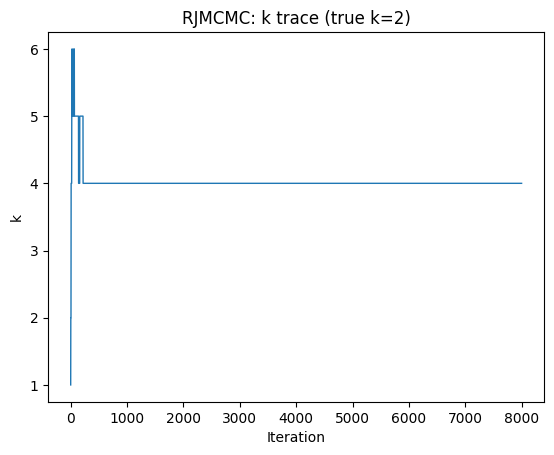

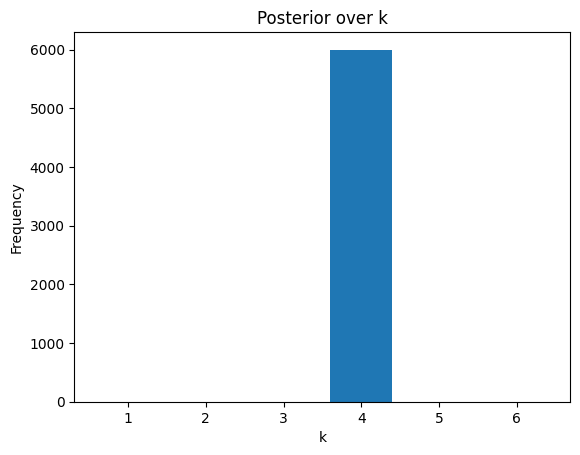

In [5]:
# at the bottom of the canvas file
out, (mu_true, sigma_true) = demo_k2_mog()
